In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


# Univariate:

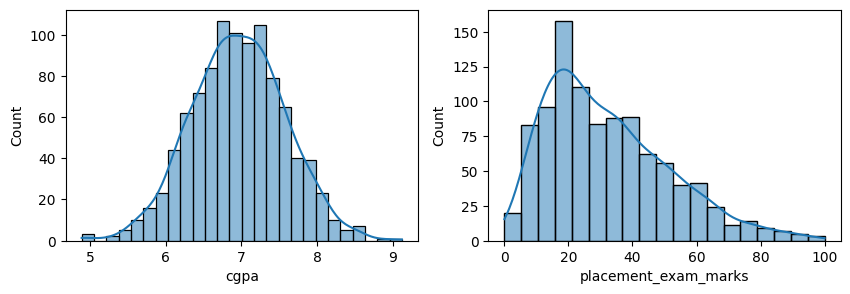

In [3]:
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.show()

In [4]:
# Cgpa column is sort of normal but exam mark is right skewed.

df.placement_exam_marks.skew()

np.float64(0.8356419499466834)

In [5]:
print("Mean value of cgpa",df['cgpa'].mean())
print("Std value of cgpa",df['cgpa'].std())
print("Min value of cgpa",df['cgpa'].min())
print("Max value of cgpa",df['cgpa'].max())

Mean value of cgpa 6.96124
Std value of cgpa 0.6158978751323894
Min value of cgpa 4.89
Max value of cgpa 9.12


# Z test :
As cgpa column is normally distributed, we know 99% data is within 3 std of mean.


In [6]:
highest_cgpa=df['cgpa'].mean()+3*df['cgpa'].std()
lowest_cgpa=df['cgpa'].mean()-3*df['cgpa'].std()

print(highest_cgpa)
print(lowest_cgpa)

# We will consider values outside of this range is outlier.

8.808933625397168
5.113546374602832


In [7]:
# outliers:

df[(df['cgpa']>highest_cgpa ) | (df['cgpa']<lowest_cgpa)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


To handle outlier, we can do trimming or capping

In [8]:
# Trimming
new_df = df[(df['cgpa'] < highest_cgpa) & (df['cgpa'] > lowest_cgpa)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


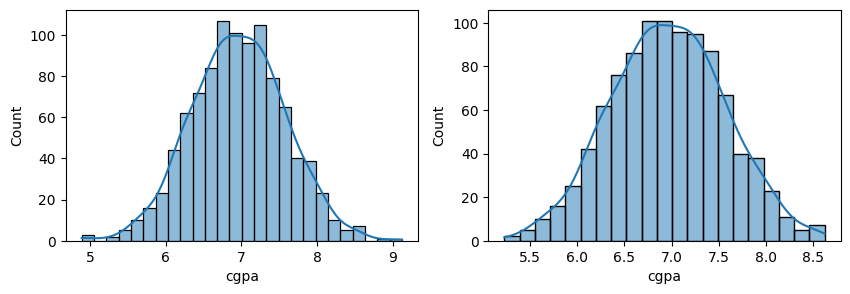

In [9]:
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(new_df['cgpa'],kde=True)

plt.show()

# We cut off the tails.

In [10]:
# Capping

capped_df=df.copy()

capped_df['cgpa']= np.where(

                     df['cgpa']>highest_cgpa, highest_cgpa,
                     np.where(df['cgpa']<lowest_cgpa,lowest_cgpa,df['cgpa'])

)

capped_df.cgpa.describe()

,cgpa
count,1000.000000
mean,6.961499
std,0.612688
min,5.113546
25%,6.550000
50%,6.960000
75%,7.370000
max,8.808934


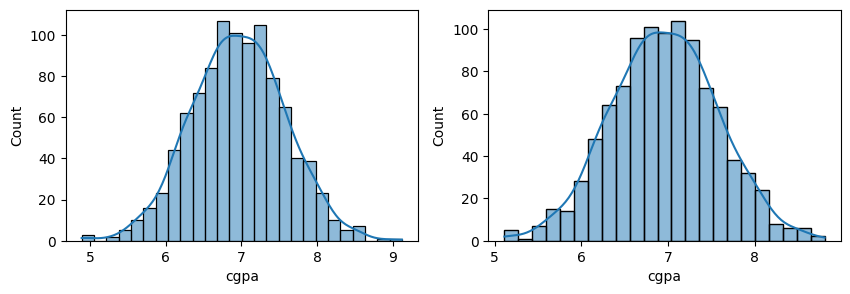

In [11]:
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(capped_df['cgpa'],kde=True)

plt.show()

# outliers are added at the tail

In [12]:
# Lets try with z score

zdf=df.copy()

zdf['cgpa_zscore'] = (zdf['cgpa'] - zdf['cgpa'].mean())/zdf['cgpa'].std()
zdf

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
998,8.62,46.0,1,2.693239


In [13]:
zdf[zdf['cgpa_zscore'] > 3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [14]:
zdf[zdf['cgpa_zscore'] < -3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


# Box plot
When data is not normal. (skewed data)

In [15]:
df.placement_exam_marks.describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

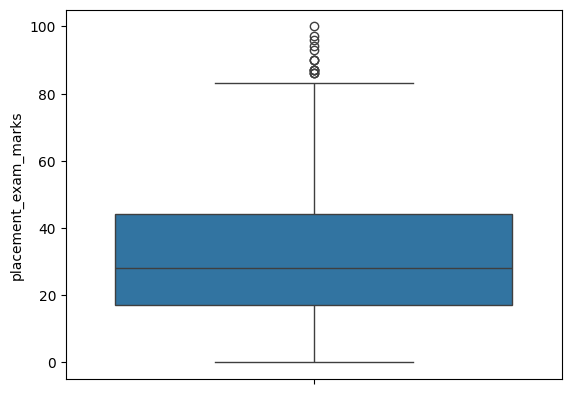

In [16]:
sns.boxplot(df['placement_exam_marks'])

In [17]:
percentile25=df['placement_exam_marks'].quantile(.25)
percentile75=df['placement_exam_marks'].quantile(.75)

print(percentile25)
print(percentile75)

17.0
44.0


In [18]:
iqr=percentile75-percentile25
print(iqr)

27.0


In [19]:
highest=percentile75+1.5*iqr
lowest=percentile25-1.5*iqr

print(highest)
print(lowest)

84.5
-23.5


In [20]:
df[df['placement_exam_marks'] > highest]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [21]:
df[df['placement_exam_marks'] < lowest]

,cgpa,placement_exam_marks,placed


In [22]:
# Trimming
trimmed_df = df[(df['placement_exam_marks'] < highest) & (df['placement_exam_marks'] > lowest)]
trimmed_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: ylabel='placement_exam_marks'>

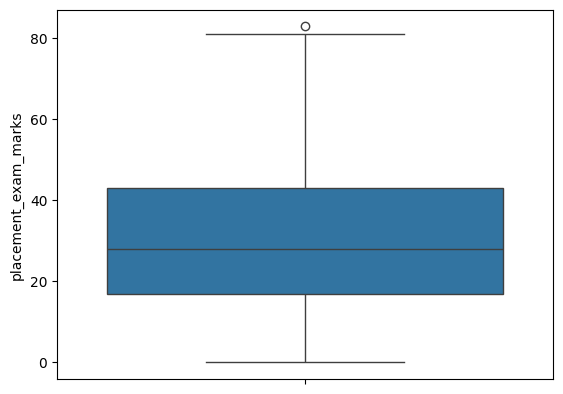

In [23]:
sns.boxplot(trimmed_df['placement_exam_marks'])

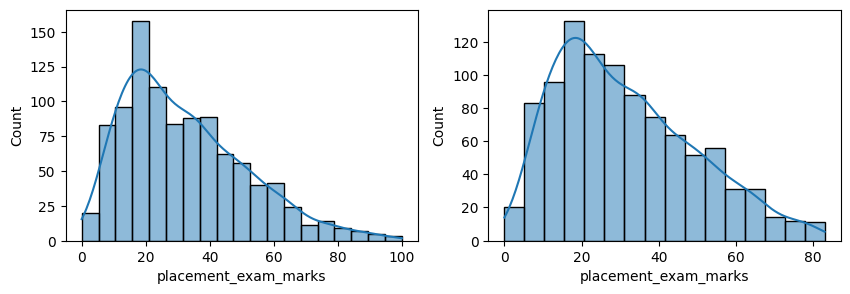

0.8356419499466834
0.6549925627115251


In [24]:
plt.figure(figsize=(10,3))

plt.subplot(1,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(1,2,2)
sns.histplot(trimmed_df['placement_exam_marks'],kde=True)

plt.show()

print(df.placement_exam_marks.skew())
print(trimmed_df.placement_exam_marks.skew())

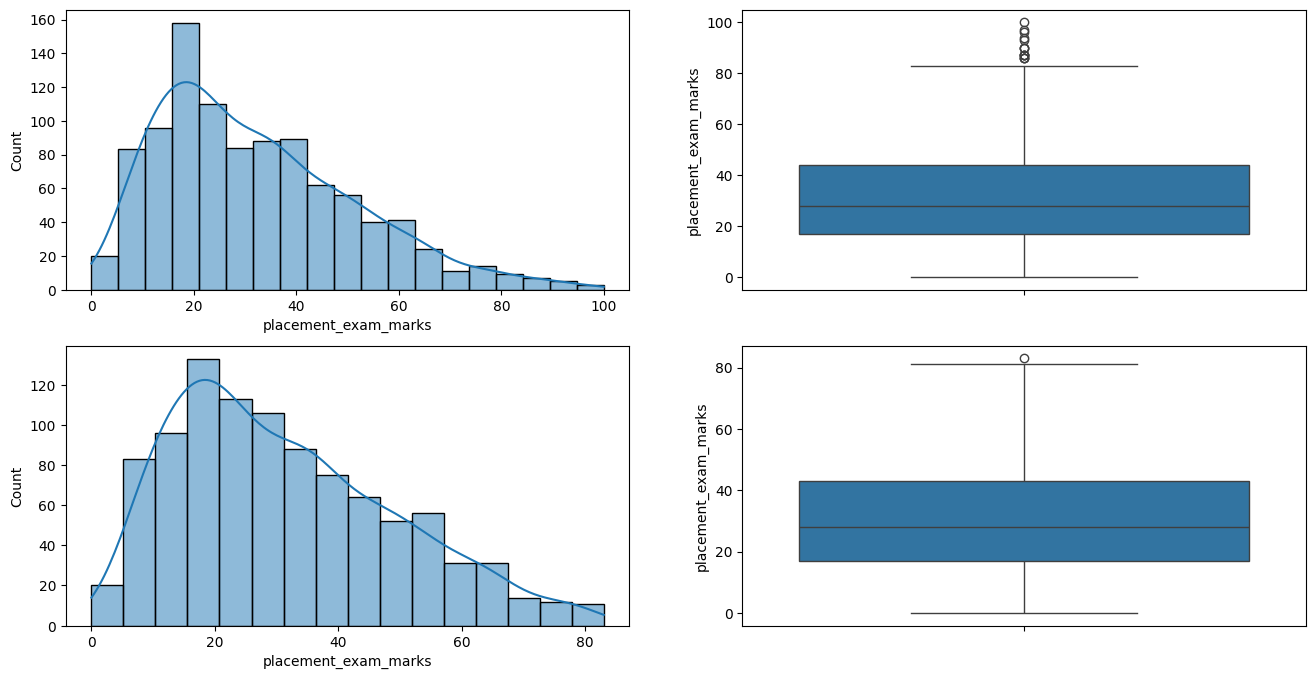

In [25]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(trimmed_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(trimmed_df['placement_exam_marks'])

plt.show()

In [26]:
# Capping

new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > highest,
    highest,
    np.where(
        new_df_cap['placement_exam_marks'] < lowest,
        lowest,
        new_df_cap['placement_exam_marks']
    )
)

new_df_cap



,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


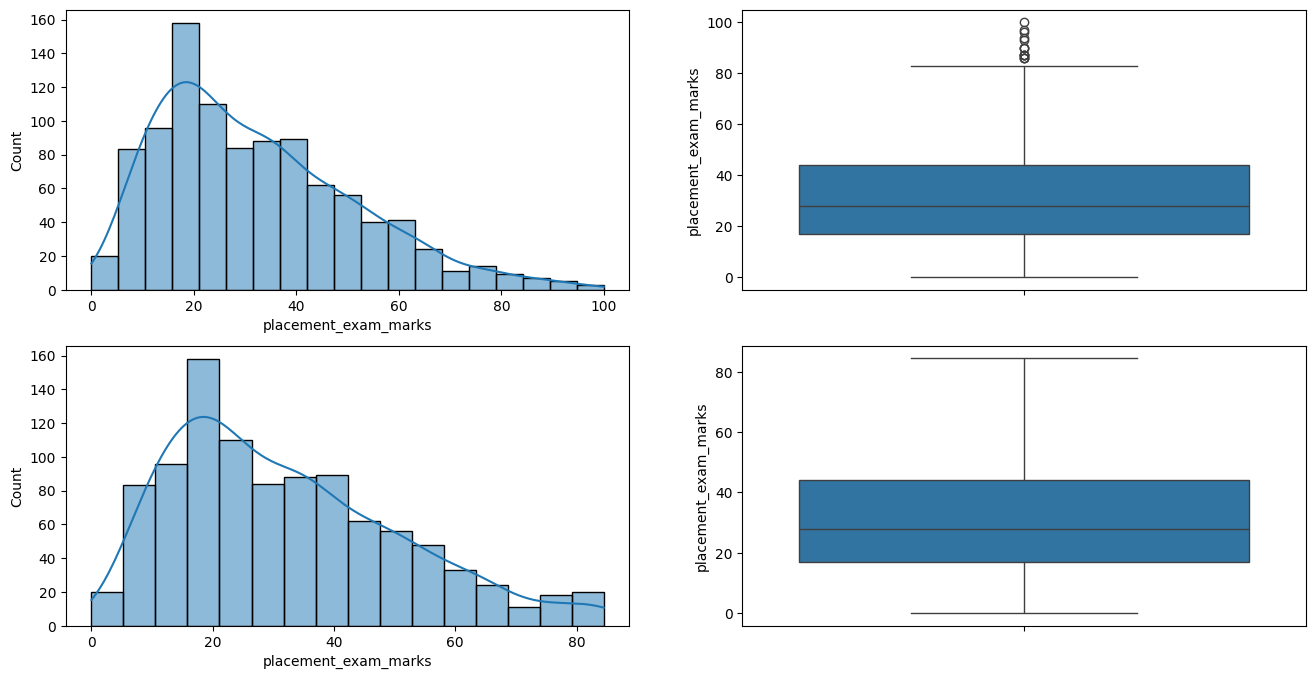

In [27]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()

  #  Multivariate:

## 1. Isolation forest

In [28]:
from sklearn.ensemble import IsolationForest

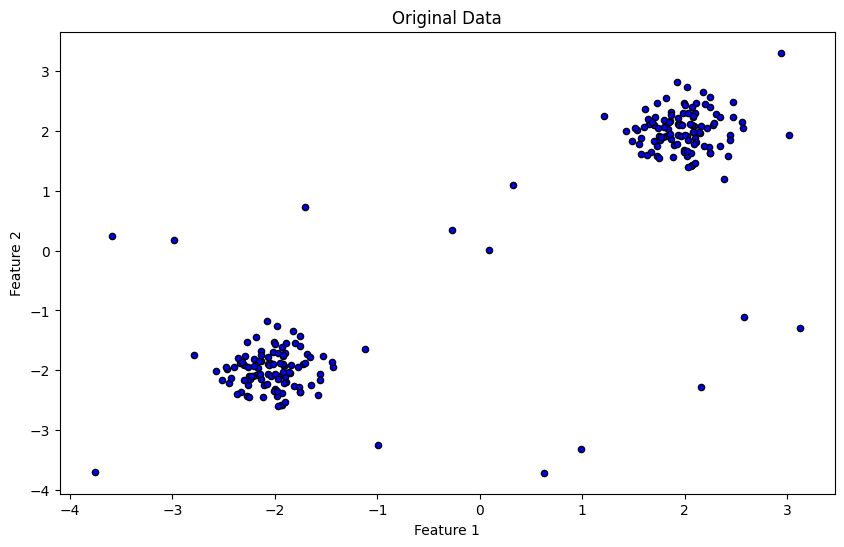

In [29]:
# Generating a sample 2D dataset
rng = np.random.RandomState(42)
X = 0.3 * rng.randn(100, 2)
X_train = np.r_[X + 2, X - 2]
X_outliers = rng.uniform(low=-4, high=4, size=(20, 2))

# Combine the datasets
X = np.r_[X_train, X_outliers]

# Plotting the dataset before outlier detection
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], color='b', s=20, edgecolor='k')
plt.title("Original Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [30]:
clf=IsolationForest(max_samples=100,random_state=42,contamination='auto')
clf.fit(X)
y_pred=clf.predict(X)

In [31]:
clf.score_samples(X)

array([-0.41255434, -0.46194202, -0.39502689, -0.50845369, -0.39766424,
       -0.40339139, -0.47788572, -0.48619491, -0.41516574, -0.47022388,
       -0.47821327, -0.44702955, -0.40386525, -0.42330045, -0.40371688,
       -0.49235606, -0.42940673, -0.4644989 , -0.4841678 , -0.43413714,
       -0.42405979, -0.40324171, -0.46345246, -0.42001668, -0.48074022,
       -0.40623312, -0.40870136, -0.45149163, -0.40460873, -0.42109317,
       -0.40167317, -0.46191168, -0.46778432, -0.4121988 , -0.41930611,
       -0.45178011, -0.45659115, -0.54891531, -0.40349426, -0.48613196,
       -0.39071986, -0.48514209, -0.40890721, -0.43718136, -0.400255  ,
       -0.41223111, -0.4038392 , -0.45771139, -0.40073964, -0.40475779,
       -0.43847688, -0.41733652, -0.39638074, -0.5197579 , -0.39879092,
       -0.50236021, -0.54034029, -0.39471777, -0.43054248, -0.45784565,
       -0.45011641, -0.5199582 , -0.51495118, -0.42283284, -0.4049726 ,
       -0.46012663, -0.41925432, -0.48175499, -0.40402538, -0.46

In [32]:
y_pred==-1

array([False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False,  True,  True, False, False, False, False,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False,  True, False, False, False, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [33]:
X[y_pred==-1]

array([[ 2.47376384,  2.23023042],
       [ 1.21407647,  2.24657075],
       [ 2.56585577,  2.05237334],
       [ 1.42436864,  1.99204584],
       [ 2.01806906,  2.73897263],
       [ 2.42083829,  1.57944468],
       [ 2.17605713,  2.65713669],
       [ 2.55973235,  2.14214988],
       [ 2.24661805,  2.56903789],
       [ 1.92060295,  2.81605075],
       [-2.78592353, -1.75342925],
       [-1.98193094, -1.26102737],
       [-2.07939705, -1.18394925],
       [ 3.01898458,  1.92614894],
       [-1.12407079, -1.65126525],
       [ 2.47488924,  2.48090716],
       [ 2.93657855,  3.30592442],
       [ 0.09073919,  0.01213036],
       [ 2.38636143,  1.19971145],
       [ 3.12004273, -1.29603875],
       [-0.99533638, -3.24814448],
       [ 0.62624113, -3.71246181],
       [-0.27521585,  0.34115708],
       [-1.70766998,  0.72666608],
       [-3.755998  , -3.70121449],
       [ 2.58080449, -1.11847487],
       [-2.9835159 ,  0.17794608],
       [ 2.15994842, -2.27343178],
       [ 0.98312381,

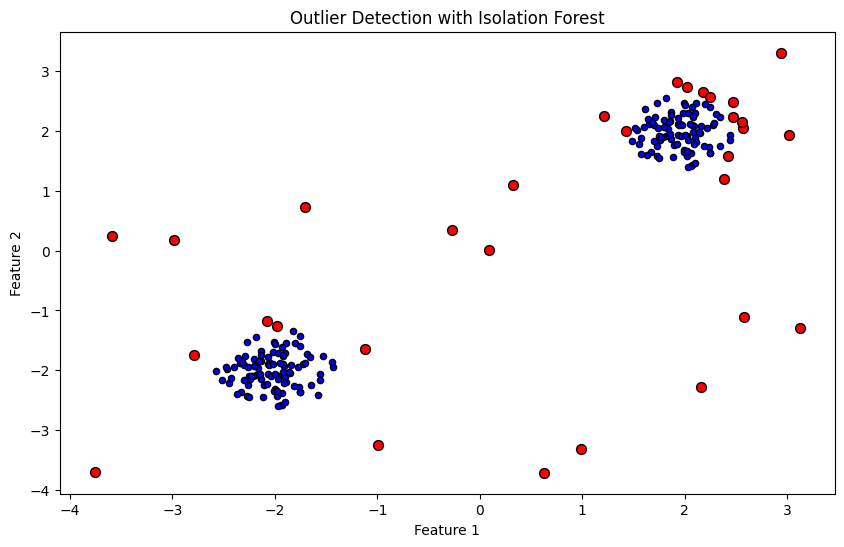

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], color='b', s=20, edgecolor='k')

# Highlighting the outliers
is_outlier = y_pred == -1
plt.scatter(X[is_outlier, 0], X[is_outlier, 1], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# KNN

In [35]:
from sklearn.neighbors import NearestNeighbors

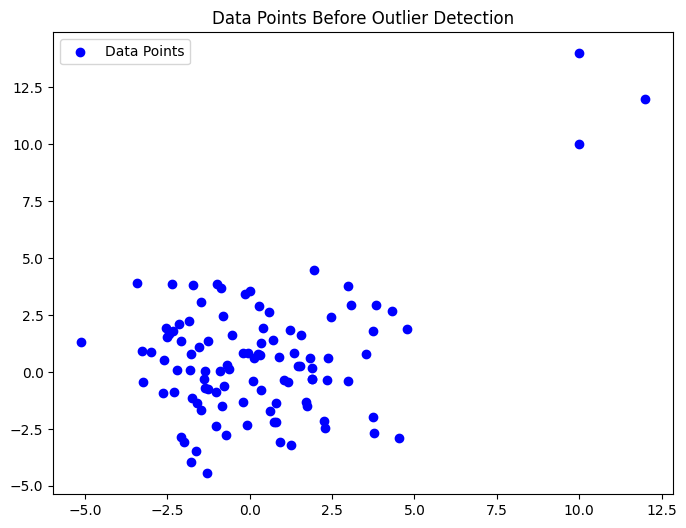

In [40]:
# Generating more sample data
np.random.seed(0)
X_normal = np.random.randn(100, 2) * 2
X_outliers = np.array([[10, 10], [12, 12], [10, 14]])
X = np.concatenate([X_normal, X_outliers], axis=0)

# Plot the data before outlier detection
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')
plt.title('Data Points Before Outlier Detection')
plt.legend()
plt.show()

In [41]:
nbrs=NearestNeighbors(n_neighbors=3)
nbrs.fit(X)
distances,indices=nbrs.kneighbors(X)

In [42]:
distances[:,1:]

array([[1.03273565, 1.16400456],
       [1.23066243, 1.89971267],
       [0.74161833, 1.24799823],
       [0.00924965, 0.4609371 ],
       [0.15420723, 0.40250067],
       [0.40065555, 0.66987119],
       [0.06554469, 0.38289747],
       [0.48010648, 0.58464192],
       [0.63261521, 1.09328932],
       [0.38276607, 0.50589927],
       [1.88463535, 2.16625804],
       [0.18291244, 0.85518395],
       [0.80206625, 1.24799823],
       [0.50354056, 0.86461556],
       [0.78064455, 0.80691278],
       [0.07358528, 0.2328001 ],
       [0.5304653 , 0.68840597],
       [0.21315516, 0.35137994],
       [0.80691278, 1.18956994],
       [0.36549916, 0.50856452],
       [0.26758084, 0.77256547],
       [1.06638957, 1.69204912],
       [0.29132572, 0.36150851],
       [0.14450617, 0.30261222],
       [0.77645811, 1.0357936 ],
       [0.39482877, 0.65146678],
       [0.49939835, 0.84896547],
       [0.15420723, 0.31463106],
       [0.2328001 , 0.23281981],
       [0.07654273, 0.29132572],
       [0.

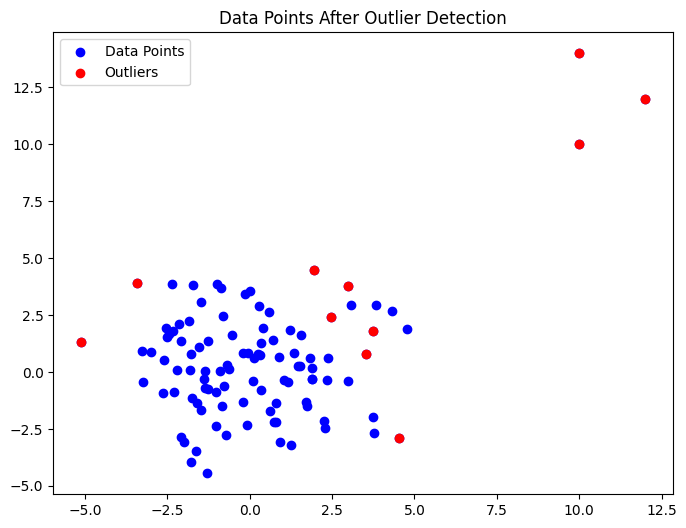

In [43]:
# Calculate the outlier score
outlier_scores = np.mean(distances[:, 1:], axis=1)

# Determine a threshold
threshold = np.percentile(outlier_scores, 90)  # using the 95th percentile as the threshold

# Identify outliers
outlier_indices = np.where(outlier_scores > threshold)[0]
outliers = X[outlier_indices]

# Plot the data after outlier detection
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='blue', label='Data Points')
plt.scatter(outliers[:, 0], outliers[:, 1], color='red', label='Outliers')
plt.title('Data Points After Outlier Detection')
plt.legend()
plt.show()

# Local Outlier Factor:

In [44]:
from sklearn.neighbors import LocalOutlierFactor
from matplotlib.legend_handler import HandlerPathCollection

# Set seed for reproducibility
np.random.seed(0)

# Generate a dense cluster
dense_cluster = np.random.normal(loc=0, scale=0.5, size=(100, 2))

# Generate a sparse cluster
sparse_cluster = np.random.normal(loc=5, scale=2.5, size=(30, 2))

# Combine the clusters
X = np.concatenate([dense_cluster, sparse_cluster])


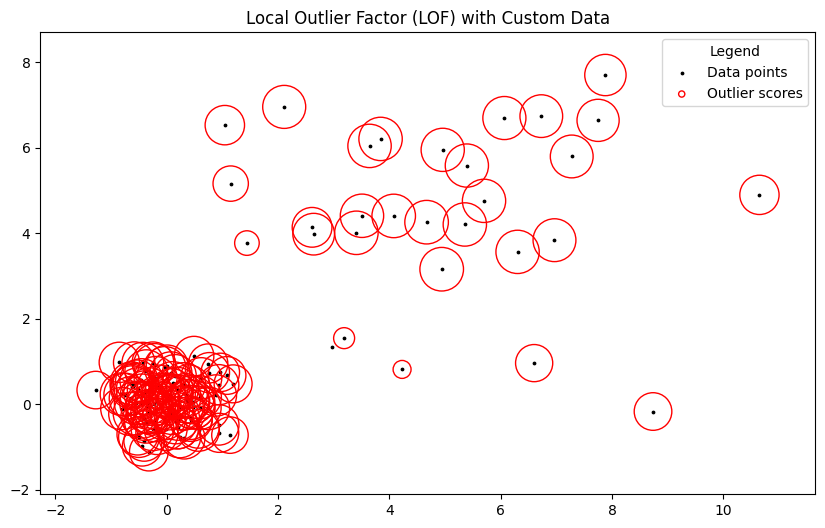

In [45]:

# Applying LOF

clf_lof = LocalOutlierFactor(n_neighbors=20)
y_pred_lof = clf_lof.fit_predict(X)
X_scores = -clf_lof.negative_outlier_factor_  # Negative scores, higher is more abnormal

# Calculate the radius of each circle, inversely proportional to the outlier score
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())

# Define a function to update legend marker size for clarity
def update_legend_marker_size(handle, orig):
    handle.update_from(orig)
    handle.set_sizes([20])

# Plotting the data points and circles representing outlier scores
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Data points")
scatter = plt.scatter(
    X[:, 0], X[:, 1],
    s=1000 * radius,  # Adjust the multiplier for circle sizes as necessary
    edgecolors="r",
    facecolors="none",
    label="Outlier scores"
)
plt.axis("tight")
plt.xlim((X[:, 0].min() - 1, X[:, 0].max() + 1))
plt.ylim((X[:, 1].min() - 1, X[:, 1].max() + 1))
plt.legend(handler_map={scatter: HandlerPathCollection(update_func=update_legend_marker_size)},
           title="Legend")
plt.title("Local Outlier Factor (LOF) with Custom Data")
plt.show()


| Feature/Technique      | Z-Score Technique                | IQR and Box Plot Method         | Isolation Forest                | KNN (k-Nearest Neighbors)      | LOF (Local Outlier Factor)     | DBSCAN (Density-Based Spatial Clustering of Applications with Noise) |
|------------------------|----------------------------------|---------------------------------|---------------------------------|--------------------------------|--------------------------------|---------------------------------------------------------------------|
| **Method Type**        | Statistical                     | Statistical                     | Ensemble Method                 | Distance-Based                 | Density-Based                  | Density-Based                                                       |
| **Approach**           | Standard deviation and mean     | Quartiles and median            | Random forest isolation         | Nearest neighbors distance     | Local density comparison       | Density-based clustering                                            |
| **Key Parameters**     | Threshold for Z-score (e.g., 3) | IQR multiplier (typically 1.5)  | Number of trees, path length    | Number of neighbors (k)        | Number of neighbors (k), radius | Epsilon (eps), MinPts                                              |
| **Sensitivity**        | Very sensitive to outliers      | Moderately sensitive            | Robust to outliers              | Sensitive to local outliers    | Sensitive to local density     | Sensitive to density variations                                     |
| **Scalability**        | Very scalable                   | Very scalable                   | Good scalability                | Poor with large datasets       | Poor with large datasets       | Poor with large datasets                                            |
| **Best Use Case**      | Gaussian-distributed data       | Non-Gaussian, not too skewed    | High-dimensional, mixed feature types | Small, low-dimensional datasets | Varying density clusters      | Spatial data with clear density gaps                                |
| **Interpretability**   | Very interpretable              | Highly interpretable            | Less interpretable              | Moderately interpretable       | Less interpretable             | Moderately interpretable                                            |
| **Advantages**         | Easy to understand and implement| Easy to understand, robust to mild outliers | Handles large feature sets well| Intuitive, effective in many scenarios | Effective in detecting outliers in varying density data | Good at identifying clusters and noise                              |
| **Disadvantages**      | Assumes normality, not good for multimodal data | Can miss outliers in a skewed distribution | Requires parameter tuning, complex | Sensitive to k, not good for high-dimensional data | Requires parameter tuning, complex | Parameters eps and MinPts can be hard to set, not ideal for high-dimensional data |
| **Output**             | Binary classification (inlier/outlier) | Binary classification (inlier/outlier) | Outlier score (continuous)     | Binary classification or score | Outlier score (continuous)     | Cluster labels (including noise)                                    |
| **Model Type**         | Unsupervised                    | Unsupervised                    | Unsupervised                    | Unsupervised or semi-supervised| Unsupervised                    | Unsupervised                                                        |
| **Data Assumption**    | Assumes feature independence    | Assumes feature independence    | No assumption on data structure | Assumes local similarity       | Assumes local similarity       | Assumes clusters are dense regions of points                        |
| **Robustness**         | Not robust to skewed data       | More robust than Z-score        | Robust to isolated noise        | Moderate robustness            | Robust to local density changes| Robust to cluster shape variations                                  |


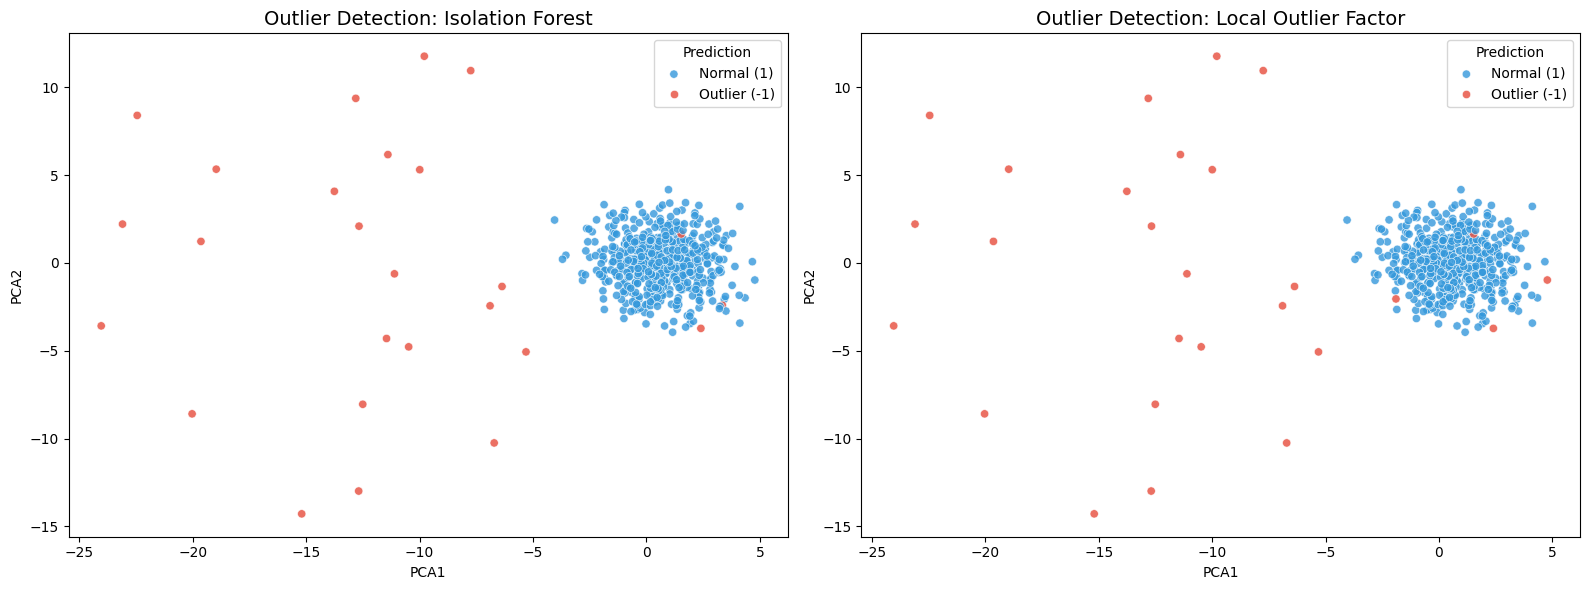

Isolation Forest vs True Labels:
IF    -1    1
True         
-1    24    1
 1     3  497

LOF vs True Labels:
LOF   -1    1
True         
-1    24    1
 1     3  497


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. Generate 5-Dimensional Data with Outliers
# ---------------------------------------------------------
np.random.seed(42)

# Generate 500 normal points grouped together in 5D space
X_normal, _ = make_blobs(n_samples=500, centers=1, n_features=5, random_state=42, cluster_std=1.5)

# Generate 25 outliers scattered randomly across a wider 5D space
X_outliers = np.random.uniform(low=-10, high=10, size=(25, 5))

# Combine into a single dataset
X = np.vstack([X_normal, X_outliers])
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5'])

# Keep track of ground truth (1 for normal, -1 for outlier)
df['True_Label'] = [1] * 500 + [-1] * 25

# ---------------------------------------------------------
# 2. Run Isolation Forest
# ---------------------------------------------------------
# We set contamination to 0.05 since we know ~5% of our data are outliers
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['IF_Label'] = iso_forest.fit_predict(df.iloc[:, :5])

# ---------------------------------------------------------
# 3. Run Local Outlier Factor (LOF)
# ---------------------------------------------------------
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['LOF_Label'] = lof.fit_predict(df.iloc[:, :5])

# ---------------------------------------------------------
# 4. EDA - Visualize Outliers using PCA
# ---------------------------------------------------------
# Reduce 5D data to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.iloc[:, :5])
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Isolation Forest Scatter Plot
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='IF_Label',
                palette={1: '#3498db', -1: '#e74c3c'}, alpha=0.8, ax=axes[0])
axes[0].set_title('Outlier Detection: Isolation Forest', fontsize=14)
axes[0].legend(title='Prediction', labels=['Normal (1)', 'Outlier (-1)'])

# LOF Scatter Plot
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='LOF_Label',
                palette={1: '#3498db', -1: '#e74c3c'}, alpha=0.8, ax=axes[1])
axes[1].set_title('Outlier Detection: Local Outlier Factor', fontsize=14)
axes[1].legend(title='Prediction', labels=['Normal (1)', 'Outlier (-1)'])

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Compare Algorithms with Ground Truth
# ---------------------------------------------------------
print("Isolation Forest vs True Labels:")
print(pd.crosstab(df['True_Label'], df['IF_Label'], rownames=['True'], colnames=['IF']))

print("\nLOF vs True Labels:")
print(pd.crosstab(df['True_Label'], df['LOF_Label'], rownames=['True'], colnames=['LOF']))